In [62]:
import pandas as pd
from utils.prob_utils import ProbUtils
import os
import numpy as np

In [63]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [64]:
pu = ProbUtils()

In [65]:
# Set up paths
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
ML_DIR_PATH = os.path.join(ROOT_DIR_PATH, "ml")
ML_OUTPUT_DIR_PATH = os.path.join(ML_DIR_PATH, "output")
ARUMA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "arima")
ARIMA_OUTPUT_DIR_PATH = os.path.join(ARUMA_DIR_PATH, "output")
ENSEMBLE_DIR_PATH = os.path.join(ARIMA_OUTPUT_DIR_PATH, "ensemble")
TRAINING_DIR_PATH = os.path.join(ML_OUTPUT_DIR_PATH, "training")
CONFIG_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "config")
MODELS_DIR_PATH = os.path.join(ML_OUTPUT_DIR_PATH, "models")
POSTPROCESSING_DIR_PATH = os.path.join(ARIMA_OUTPUT_DIR_PATH, "postprocessed_ensemble")
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
RAW_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "raw_data")
NDC_DATA_DIR_PATH = os.path.join(RAW_DATA_DIR_PATH, "ndc")
NDC_POSTPROCESSED_DIR_PATH = os.path.join(DATA_DIR_PATH, "ndc_data")

### Load and explore the NDC target data

In [66]:
#NOTE: The emission values of this databse are in mtons
ndc_ref = pd.read_excel(os.path.join(NDC_POSTPROCESSED_DIR_PATH, "ndc_reference_combined.xlsx"), sheet_name="base_2020")
ndc_ref.head()

,region,iso_alpha_3,unconditional,conditional,2020,unconditional_b20,conditional_b20,2020_excl_lulucf,2015_ref,2015_excl_lulucf_ref,source,flags
0,Afghanistan,AFG,51.7,45.5,34.309517,0.506871,0.326163,34.154859,31.227612,31.473832,Climate Watch NDC Tracker (WRI),NaN
1,Albania,ALB,12.0,12.0,8.351838,0.436810,0.436810,8.598221,8.557192,9.408664,Climate Watch NDC Tracker (WRI),NaN
2,Algeria,DZA,288.1,241.0,272.628149,0.056751,-0.116012,272.319925,265.178075,265.798290,Climate Watch NDC Tracker (WRI),NaN
3,Andorra,AND,0.3,0.3,0.509745,-0.411471,-0.411471,0.509745,0.579229,0.579229,Climate Watch NDC Tracker (WRI),NaN
4,Angola,AGO,27.6,-1.4,133.309538,-0.792963,-1.010502,83.554611,158.769586,105.853832,Climate Watch NDC Tracker (WRI),neg_cond_lulucf


In [67]:
ndc_ref.describe()

,unconditional,conditional,2020,unconditional_b20,conditional_b20,2020_excl_lulucf,2015_ref,2015_excl_lulucf_ref
count,198.000000,198.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000
mean,254.950056,234.539955,253.764445,0.054620,-0.181702,247.426907,250.688342,248.577900
std,1050.531366,1044.996825,1009.331434,0.833282,0.918273,1057.826138,960.153869,1019.466360
min,-206.000000,-369.400000,-0.810944,-5.400433,-8.890874,0.007683,-180.761941,0.007440
25%,7.587682,5.925000,9.819481,-0.246563,-0.375012,8.247640,8.594435,8.200718
50%,40.945373,34.002075,42.617389,0.017680,-0.104946,36.001057,35.672384,33.817702
75%,121.925000,101.925000,131.454269,0.287351,0.121743,101.021371,126.775853,104.623660
max,13153.400000,13153.400000,12107.803810,4.149031,2.071955,12755.048710,11012.140850,11719.650090


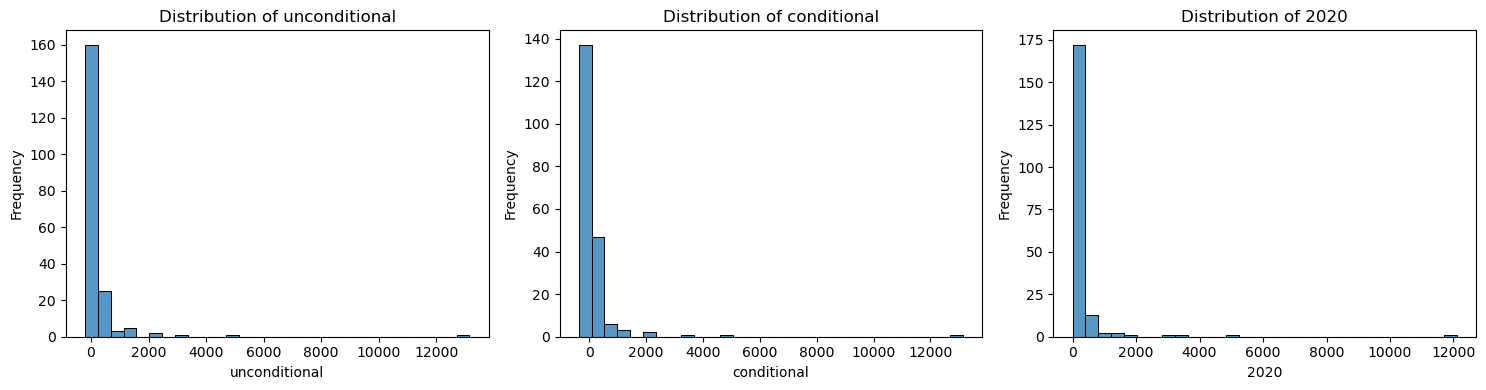

In [68]:
pu.plot_column_distributions(ndc_ref, ["unconditional", "conditional", "2020"], kde=False)

In [69]:
ndc_ref["iso_alpha_3"].unique()

array(['AFG', 'ALB', 'DZA', 'AND', 'AGO', 'ATG', 'ARG', 'ARM', 'AUS',
       'AUT', 'AZE', 'BHR', 'BGD', 'BRB', 'BLR', 'BEL', 'BLZ', 'BEN',
       'BTN', 'BOL', 'BIH', 'BWA', 'BRA', 'BRN', 'BGR', 'BFA', 'BDI',
       'KHM', 'CMR', 'CAN', 'CPV', 'CAF', 'TCD', 'CHL', 'CHN', 'COL',
       'COM', 'COK', 'CRI', 'HRV', 'CUB', 'CYP', 'CZE', 'COD', 'DNK',
       'DJI', 'DMA', 'DOM', 'ECU', 'EGY', 'SLV', 'GNQ', 'ERI', 'EST',
       'SWZ', 'ETH', 'EUU', 'FSM', 'FJI', 'FIN', 'FRA', 'GAB', 'GMB',
       'GEO', 'DEU', 'GHA', 'GRC', 'GRD', 'GTM', 'GIN', 'GNB', 'GUY',
       'HTI', 'VAT', 'HND', 'HUN', 'ISL', 'IND', 'IDN', 'IRN', 'IRQ',
       'IRL', 'ISR', 'ITA', 'CIV', 'JAM', 'JPN', 'JOR', 'KAZ', 'KEN',
       'KIR', 'KWT', 'KGZ', 'LAO', 'LVA', 'LBN', 'LSO', 'LBR', 'LBY',
       'LIE', 'LTU', 'LUX', 'MDG', 'MWI', 'MYS', 'MDV', 'MLI', 'MLT',
       'MHL', 'MRT', 'MUS', 'MEX', 'MDA', 'MCO', 'MNG', 'MNE', 'MAR',
       'MOZ', 'MMR', 'NAM', 'NRU', 'NPL', 'NLD', 'NZL', 'NIC', 'NER',
       'NGA', 'NIU',

In [70]:
ndc_ref[ndc_ref.region=="Japan"]

,region,iso_alpha_3,unconditional,conditional,2020,unconditional_b20,conditional_b20,2020_excl_lulucf,2015_ref,2015_excl_lulucf_ref,source,flags
86,Japan,JPN,760.3,760.3,1058.627502,-0.281806,-0.281806,1090.403946,1214.872102,1264.326973,Climate Watch NDC Tracker (WRI),NaN


### Re-calculate the unconditional and conditional targets using the historical edgar data

In [71]:
run_id = 1773188058
log_emissions_field_name = "x_log_signed_con_edgar_ghg_mt"


base_df = pd.read_csv(os.path.join(TRAINING_DIR_PATH, f"training_df_{run_id}.csv"))

base_df_filtered = base_df[base_df["year"] == 2020][["iso_alpha_3", log_emissions_field_name]]
base_df_filtered["2020_edgar_ghg_mt"] = np.expm1(base_df_filtered[log_emissions_field_name])
base_df_filtered.head()


,iso_alpha_3,x_log_signed_con_edgar_ghg_mt,2020_edgar_ghg_mt
15,AFG,3.372478,28.150674
33,AGO,4.286101,71.682513
51,ALB,2.181897,7.863104
69,ARG,5.886175,359.025664
87,ARM,2.379782,9.802551


In [72]:
# Merge the NDC reference data with the base data to calculate the unconditional and conditional targets using the base emissions for 2020
print("# of iso in NDC reference data:", ndc_ref["iso_alpha_3"].nunique())
print("# of iso in base data:", base_df_filtered["iso_alpha_3"].nunique())

ndc_ref_base = ndc_ref.merge(base_df_filtered, on="iso_alpha_3", how="right")
print("# of iso in merged data:", ndc_ref_base["iso_alpha_3"].nunique())
ndc_ref_base["unconditional_target"] = (1 + ndc_ref_base["unconditional_b20"]) * ndc_ref_base["2020_edgar_ghg_mt"]
ndc_ref_base["conditional_target"] = (1 + ndc_ref_base["conditional_b20"]) * ndc_ref_base["2020_edgar_ghg_mt"]
ndc_ref_base.head()

# of iso in NDC reference data: 198
# of iso in base data: 136
# of iso in merged data: 136


,region,iso_alpha_3,unconditional,conditional,2020,unconditional_b20,conditional_b20,2020_excl_lulucf,2015_ref,2015_excl_lulucf_ref,source,flags,x_log_signed_con_edgar_ghg_mt,2020_edgar_ghg_mt,unconditional_target,conditional_target
0,Afghanistan,AFG,51.7,45.5,34.309517,0.506871,0.326163,34.154859,31.227612,31.473832,Climate Watch NDC Tracker (WRI),NaN,3.372478,28.150674,42.419422,37.332373
1,Angola,AGO,27.6,-1.4,133.309538,-0.792963,-1.010502,83.554611,158.769586,105.853832,Climate Watch NDC Tracker (WRI),neg_cond_lulucf,4.286101,71.682513,14.840929,-0.752801
2,Albania,ALB,12.0,12.0,8.351838,0.436810,0.436810,8.598221,8.557192,9.408664,Climate Watch NDC Tracker (WRI),NaN,2.181897,7.863104,11.297782,11.297782
3,Argentina,ARG,349.0,349.0,390.839275,-0.107050,-0.107050,357.390401,437.658182,369.541953,Climate Watch NDC Tracker (WRI),NaN,5.886175,359.025664,320.592031,320.592031
4,Armenia,ARM,15.1,10.6,10.087433,0.496912,0.050812,10.046561,9.078414,9.156502,Climate Watch NDC Tracker (WRI),NaN,2.379782,9.802551,14.673556,10.300642


In [73]:
# ndc_ref_base.to_clipboard(index=False)

In [74]:
ndc_ref_base = ndc_ref_base[
    [
        "region",
        "iso_alpha_3",
        "2020_edgar_ghg_mt",
        "unconditional_target",
        "conditional_target"
    ]
].reset_index(drop=True)
ndc_ref_base.head()

,region,iso_alpha_3,2020_edgar_ghg_mt,unconditional_target,conditional_target
0,Afghanistan,AFG,28.150674,42.419422,37.332373
1,Angola,AGO,71.682513,14.840929,-0.752801
2,Albania,ALB,7.863104,11.297782,11.297782
3,Argentina,ARG,359.025664,320.592031,320.592031
4,Armenia,ARM,9.802551,14.673556,10.300642


In [75]:
ndc_ref_base.tail()

,region,iso_alpha_3,2020_edgar_ghg_mt,unconditional_target,conditional_target
131,United States of America,USA,5615.567418,3491.492730,3491.492730
132,Uzbekistan,UZB,211.861638,413.690503,413.690503
133,South Africa,ZAF,551.464312,419.555716,349.629763
134,Zambia,ZMB,28.953793,21.743778,15.295623
135,Zimbabwe,ZWE,28.341567,18.858741,11.180182


In [77]:
# check if there are any missing values
ndc_ref_base.isnull().sum()

region                  0
iso_alpha_3             0
2020_edgar_ghg_mt       0
unconditional_target    0
conditional_target      0
dtype: int64

### Load projected data and calculate probability of meeting the targets in 2030

In [78]:
projected_df = pd.read_parquet(
    os.path.join(
        POSTPROCESSING_DIR_PATH,
        f"postprocessed_ensemble_{run_id}.parquet"
    )
)

projected_df.head()

,future_id,iso_alpha_3,year,con_edgar_ghg_mt_hp_trend
0,id_AFG_10,AFG,2022,28.630028
1,id_AFG_10,AFG,2023,28.099834
2,id_AFG_10,AFG,2024,27.506961
3,id_AFG_10,AFG,2025,26.781931
4,id_AFG_10,AFG,2026,26.102022


In [79]:
target_evaluation_df = pu.ndc_summary(
    projected_df=projected_df,
    ndc_df=ndc_ref_base,
    cap_cols=["unconditional_target", "conditional_target"],
    year=2030
)

print("# of iso in target evaluation data:", target_evaluation_df["iso_alpha_3"].nunique())
target_evaluation_df.head()

# of iso in target evaluation data: 124


,iso_alpha_3,n_futures,meets_ndc_unconditional_target,meets_ndc_conditional_target
0,AFG,958,0.420668,0.338205
1,ALB,992,1.000000,1.000000
2,ARG,991,0.002018,0.002018
3,ARM,995,1.000000,0.541709
4,AUT,988,0.052632,0.052632


In [80]:
target_evaluation_df[target_evaluation_df.iso_alpha_3 == "COL"]

,iso_alpha_3,n_futures,meets_ndc_unconditional_target,meets_ndc_conditional_target


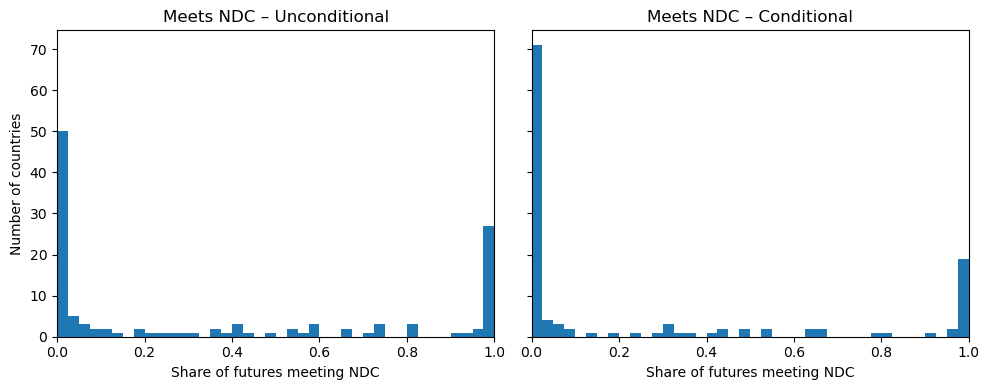

In [81]:
pu.plot_ndc_meets_histograms(
    df=target_evaluation_df,
    bins=40
)

In [82]:
target_evaluation_df.describe()

,n_futures,meets_ndc_unconditional_target,meets_ndc_conditional_target
count,124.000000,124.000000,124.000000
mean,989.346774,0.377494,0.261018
std,6.431685,0.419025,0.387085
min,958.000000,0.000000,0.000000
25%,986.750000,0.000000,0.000000
50%,990.500000,0.135251,0.000000
75%,994.000000,0.848918,0.488884
max,1000.000000,1.000000,1.000000


In [84]:
country_list_df = ndc_ref_base[["region", "iso_alpha_3"]].drop_duplicates()
country_list_df

,region,iso_alpha_3
0,Afghanistan,AFG
1,Angola,AGO
2,Albania,ALB
3,Argentina,ARG
4,Armenia,ARM
...,...,...
131,United States of America,USA
132,Uzbekistan,UZB
133,South Africa,ZAF
134,Zambia,ZMB


In [85]:
projected_df

,future_id,iso_alpha_3,year,con_edgar_ghg_mt_hp_trend
0,id_AFG_10,AFG,2022,28.630028
1,id_AFG_10,AFG,2023,28.099834
2,id_AFG_10,AFG,2024,27.506961
3,id_AFG_10,AFG,2025,26.781931
4,id_AFG_10,AFG,2026,26.102022
...,...,...,...,...
1104106,id_ZWE_999,ZWE,2026,28.247924
1104107,id_ZWE_999,ZWE,2027,27.307249
1104108,id_ZWE_999,ZWE,2028,26.126563
1104109,id_ZWE_999,ZWE,2029,24.756942


In [86]:
q1_mean_2030_df = pu.compute_2030_q1_mean(
    projected_df
)

q1_mean_2030_df.head()

,iso_alpha_3,2030_q1_mean_value
0,AFG,24.213414
1,ALB,0.327483
2,ARG,365.138759
3,ARM,8.679234
4,AUT,70.454569


In [87]:
ndc_ref_base

,region,iso_alpha_3,2020_edgar_ghg_mt,unconditional_target,conditional_target
0,Afghanistan,AFG,28.150674,42.419422,37.332373
1,Angola,AGO,71.682513,14.840929,-0.752801
2,Albania,ALB,7.863104,11.297782,11.297782
3,Argentina,ARG,359.025664,320.592031,320.592031
4,Armenia,ARM,9.802551,14.673556,10.300642
...,...,...,...,...,...
131,United States of America,USA,5615.567418,3491.492730,3491.492730
132,Uzbekistan,UZB,211.861638,413.690503,413.690503
133,South Africa,ZAF,551.464312,419.555716,349.629763
134,Zambia,ZMB,28.953793,21.743778,15.295623


In [88]:
target_evaluation_df

,iso_alpha_3,n_futures,meets_ndc_unconditional_target,meets_ndc_conditional_target
0,AFG,958,0.420668,0.338205
1,ALB,992,1.000000,1.000000
2,ARG,991,0.002018,0.002018
3,ARM,995,1.000000,0.541709
4,AUT,988,0.052632,0.052632
...,...,...,...,...
119,URY,985,0.818274,0.634518
120,USA,990,0.000000,0.000000
121,UZB,996,1.000000,1.000000
122,ZMB,991,0.000000,0.000000


In [89]:
prob_analysis_df = target_evaluation_df.merge(ndc_ref_base, how="left", on="iso_alpha_3").merge(q1_mean_2030_df, how="left", on="iso_alpha_3")
prob_analysis_df.head()

,iso_alpha_3,n_futures,meets_ndc_unconditional_target,meets_ndc_conditional_target,region,2020_edgar_ghg_mt,unconditional_target,conditional_target,2030_q1_mean_value
0,AFG,958,0.420668,0.338205,Afghanistan,28.150674,42.419422,37.332373,24.213414
1,ALB,992,1.000000,1.000000,Albania,7.863104,11.297782,11.297782,0.327483
2,ARG,991,0.002018,0.002018,Argentina,359.025664,320.592031,320.592031,365.138759
3,ARM,995,1.000000,0.541709,Armenia,9.802551,14.673556,10.300642,8.679234
4,AUT,988,0.052632,0.052632,Austria,78.305917,69.144000,69.144000,70.454569


In [90]:
TABLES_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "tables")
prob_analysis_df.to_csv(os.path.join(TABLES_DIR_PATH, f"ndc_probability_analysis_{run_id}.csv"), index=False)

In [91]:
total_countries = prob_analysis_df['iso_alpha_3'].nunique()
total_countries_with_prob = prob_analysis_df[prob_analysis_df['meets_ndc_unconditional_target'] > 0.5]['iso_alpha_3'].nunique()

print(f"Number of countries in the analysis: {total_countries}")
print(f"Percentage of countries having > 50% probability of meeting the unconditional target: {(total_countries_with_prob / total_countries * 100):.2f}%")

Number of countries in the analysis: 124
Percentage of countries having > 50% probability of meeting the unconditional target: 37.10%


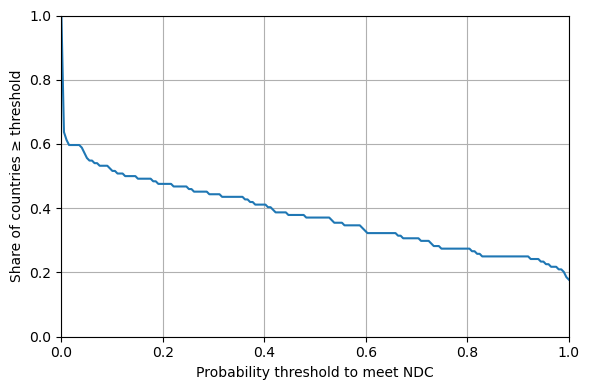

In [92]:
pu.plot_share_countries_above_probability(
    target_evaluation_df,
    prob_col="meets_ndc_unconditional_target"
)